# RetailIQ

## Exploratory Data Analysis (EDA)

In [2]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Ensure project root is in sys.path
project_root = Path.cwd()
while not (project_root / "config" / "config.yaml").exists() and project_root.parent != project_root:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data.data_loader import load_config, load_raw_data, clean_data

# Visual styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

print(f"Project root resolved: {project_root}")

Project root resolved: c:\Users\dxt\Desxtop\ML_Engineer\RetailIQ


## 1. Configuration & Data Ingestion

In [3]:
config = load_config("config/config.yaml")
raw_df = load_raw_data(config)
print(f"Raw dataset shape: {raw_df.shape}")
raw_df.head()

Raw dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Defensive Data Cleaning

In [4]:
clean_df = clean_data(raw_df, config)
print(f"Cleaned dataset shape: {clean_df.shape}")
clean_df.head()

Cleaned dataset shape: (392692, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 3. High-Level Macro Summary

In [5]:
reports_dir = Path(config["paths"]["reports_dir"])
reports_dir.mkdir(parents=True, exist_ok=True)

qty_col = config["data"]["quantity_col"]
price_col = config["data"]["price_col"]
date_col = config["data"]["date_column"]
desc_col = config["data"]["description_col"]
country_col = config["data"]["country_col"]
customer_col = config["data"]["customer_id_col"]
invoice_col = config["data"]["invoice_col"]

total_revenue = clean_df["TotalPrice"].sum()
unique_invoices = clean_df[invoice_col].nunique()
unique_customers = clean_df[customer_col].nunique()
unique_products = clean_df[desc_col].nunique()
unique_countries = clean_df[country_col].nunique()
aov = total_revenue / unique_invoices if unique_invoices > 0 else 0

summary_data = {
    "Metric": [
        "Total Valid Transactions",
        "Date Range Start",
        "Date Range End",
        "Unique Customers",
        "Unique Products (SKUs)",
        "Unique Invoices",
        "Unique Countries",
        "Gross Revenue ($)",
        "Average Order Value ($)"
    ],
    "Value": [
        f"{len(clean_df):,}",
        str(clean_df[date_col].min()),
        str(clean_df[date_col].max()),
        f"{unique_customers:,}",
        f"{unique_products:,}",
        f"{unique_invoices:,}",
        f"{unique_countries:,}",
        f"${total_revenue:,.2f}",
        f"${aov:,.2f}"
    ]
}

summary_df = pd.DataFrame(summary_data)

# Save to reports/eda_summary.txt
summary_path = reports_dir / "eda_summary.txt"
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(f"Total Rows: {len(clean_df)}\n")
    f.write(f"Date Range: {clean_df[date_col].min()} to {clean_df[date_col].max()}\n")
    f.write(f"Unique Customers: {unique_customers}\n")
    f.write(f"Unique Products: {unique_products}\n")
    f.write(f"Unique Invoices: {unique_invoices}\n")
    f.write(f"Unique Countries: {unique_countries}\n")
    f.write(f"Total Revenue: {total_revenue:.2f}\n")
    f.write(f"Avg Order Value: {aov:.2f}\n")

print(f"Summary report written to: {summary_path}")
summary_df

Summary report written to: C:\Users\dxt\Desxtop\ML_Engineer\RetailIQ\reports\eda_summary.txt


,Metric,Value
0,Total Valid Transactions,"392,692"
1,Date Range Start,2010-12-01 08:26:00
2,Date Range End,2011-12-09 12:50:00
3,Unique Customers,"4,338"
4,Unique Products (SKUs),"3,877"
5,Unique Invoices,"18,532"
6,Unique Countries,37
7,Gross Revenue ($),"$8,887,208.89"
8,Average Order Value ($),$479.56


## 4. Distribution Analysis: Quantity & Unit Price

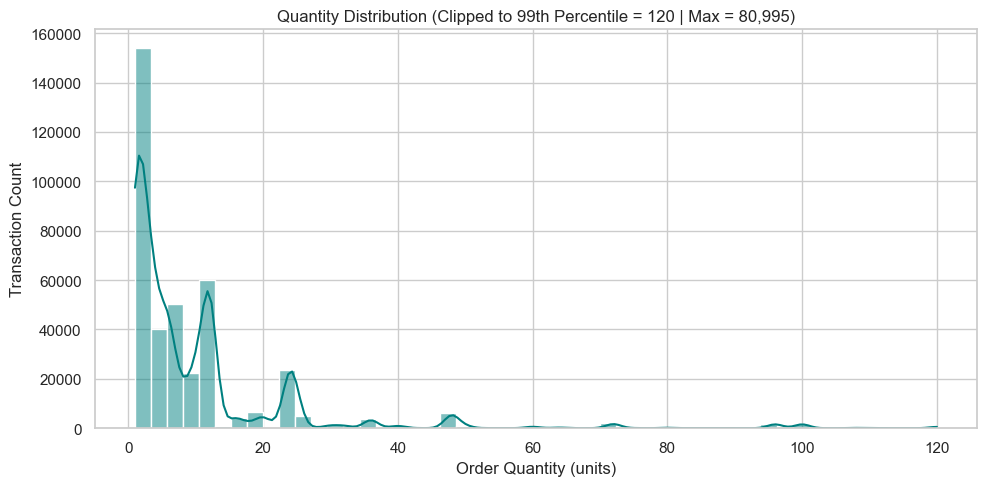

In [6]:
p99_qty = clean_df[qty_col].quantile(0.99)
max_qty = clean_df[qty_col].max()

plt.figure(figsize=(10, 5))
sns.histplot(clean_df[clean_df[qty_col] <= p99_qty][qty_col], bins=50, kde=True, color="teal")
plt.title(f"Quantity Distribution (Clipped to 99th Percentile = {p99_qty:.0f} | Max = {max_qty:,})")
plt.xlabel("Order Quantity (units)")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.savefig(reports_dir / "quantity_distribution.png", dpi=150)
plt.show()

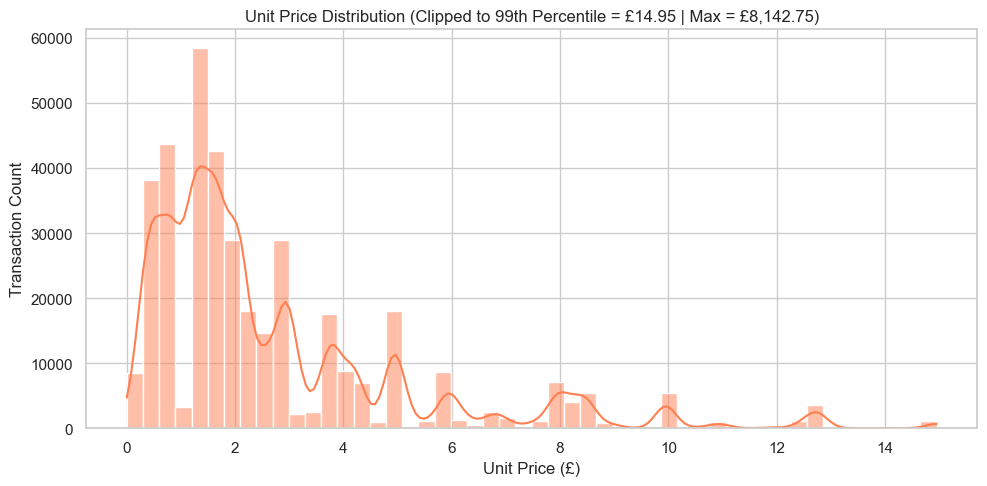

In [7]:
p99_price = clean_df[price_col].quantile(0.99)
max_price = clean_df[price_col].max()

plt.figure(figsize=(10, 5))
sns.histplot(clean_df[clean_df[price_col] <= p99_price][price_col], bins=50, kde=True, color="coral")
plt.title(f"Unit Price Distribution (Clipped to 99th Percentile = £{p99_price:.2f} | Max = £{max_price:,.2f})")
plt.xlabel("Unit Price (£)")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.savefig(reports_dir / "unit_price_distribution.png", dpi=150)
plt.show()

## 5. Temporal Sales Trends & Seasonality

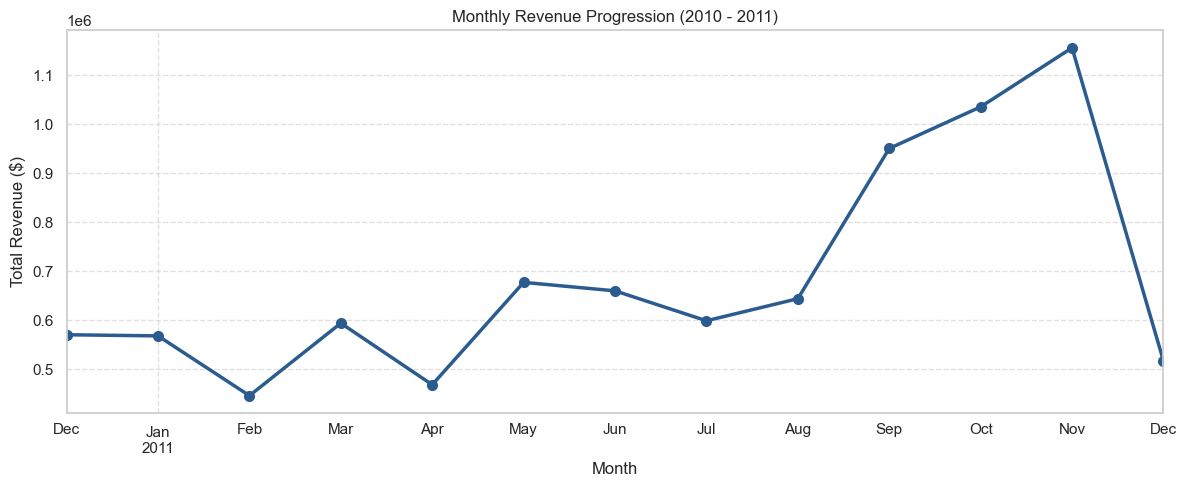

,Revenue ($),MoM Growth (%)
InvoiceDate,,
2010-12-31 00:00:00,"$570,422.73",+nan%
2011-01-31 00:00:00,"$568,101.31",-0.4%
2011-02-28 00:00:00,"$446,084.92",-21.5%
2011-03-31 00:00:00,"$594,081.76",+33.2%
2011-04-30 00:00:00,"$468,374.33",-21.2%
2011-05-31 00:00:00,"$677,355.15",+44.6%
2011-06-30 00:00:00,"$660,046.05",-2.6%
2011-07-31 00:00:00,"$598,962.90",-9.3%
2011-08-31 00:00:00,"$644,051.04",+7.5%


In [8]:
try:
    df_monthly = clean_df.set_index(date_col).resample("ME")["TotalPrice"].sum()
except ValueError:
    df_monthly = clean_df.set_index(date_col).resample("M")["TotalPrice"].sum()

plt.figure(figsize=(12, 5))
df_monthly.plot(kind="line", marker="o", color="#2b5c8f", linewidth=2.5, markersize=7)
plt.title("Monthly Revenue Progression (2010 - 2011)")
plt.xlabel("Month")
plt.ylabel("Total Revenue ($)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(reports_dir / "monthly_sales_trend.png", dpi=150)
plt.show()

monthly_df = df_monthly.to_frame(name="Revenue ($)")
monthly_df["MoM Growth (%)"] = monthly_df["Revenue ($)"].pct_change() * 100
monthly_df.style.format({"Revenue ($)": "${:,.2f}", "MoM Growth (%)": "{:+.1f}%"})

## 6. Product & Geographic Concentration

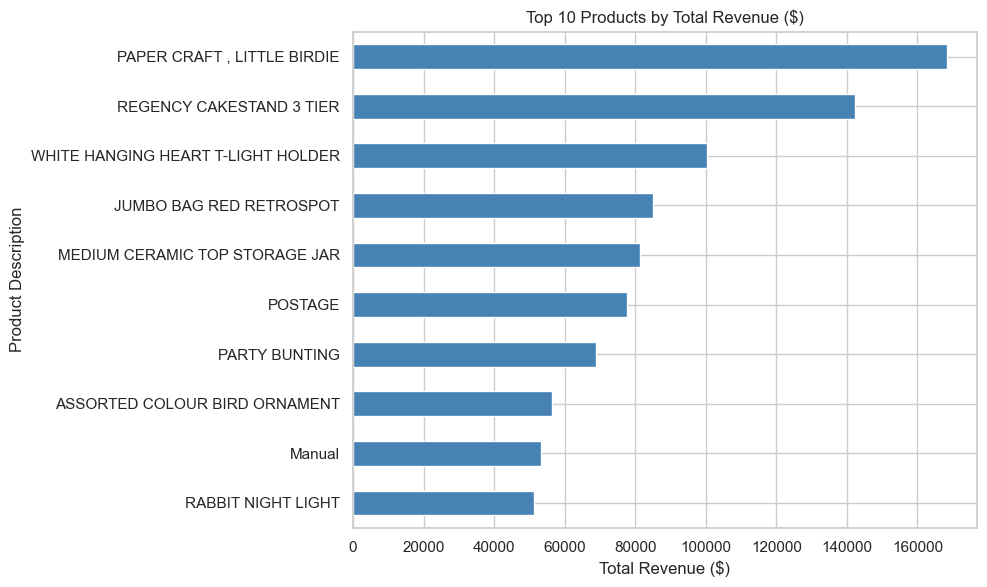

In [9]:
top_products = clean_df.groupby(desc_col)["TotalPrice"].sum().nlargest(10).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
top_products.plot(kind="barh", color="#4682b4")
plt.title("Top 10 Products by Total Revenue ($)")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Product Description")
plt.tight_layout()
plt.savefig(reports_dir / "top_10_products.png", dpi=150)
plt.show()

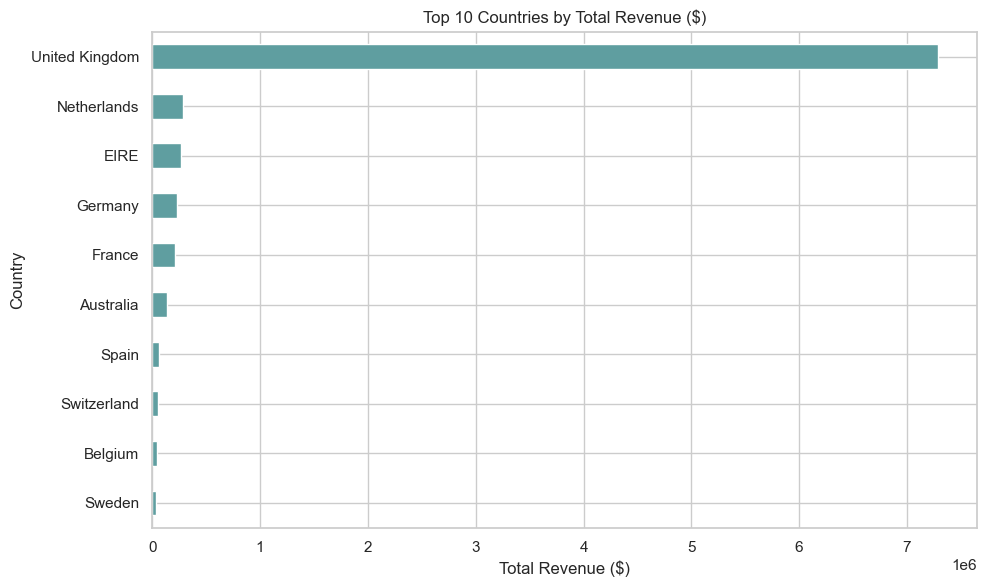

United Kingdom revenue share: 81.97% ($7,285,024.64 of $8,887,208.89)


In [10]:
top_countries = clean_df.groupby(country_col)["TotalPrice"].sum().nlargest(10).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
top_countries.plot(kind="barh", color="#5f9ea0")
plt.title("Top 10 Countries by Total Revenue ($)")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig(reports_dir / "top_10_countries.png", dpi=150)
plt.show()

uk_rev = top_countries.get("United Kingdom", 0)
uk_share = (uk_rev / total_revenue) * 100
print(f"United Kingdom revenue share: {uk_share:.2f}% (${uk_rev:,.2f} of ${total_revenue:,.2f})")

## 7. Conclusions & Modeling Implications
1. **Outlier Treatment**: Severe right-skew in Quantity and Unit Price indicates customer-level spend will have extreme outliers. Log-transforms or robust clustering strategies are recommended.
2. **Seasonality**: Heavy revenue weighting in Q4 (Sep–Nov) suggests customer recency values will be strongly shaped by year-end transaction volume.
3. **Core Market**: UK-dominated market (>82%) implies domestic versus international customer behavior can also be explored in feature engineering.